# AI4I 2020 Predictive Maintenance

## Objective

Develop a machine learning model that predicts machine failure using industrial sensor measurements.

## Business Problem

Unexpected machine failures increase downtime, maintenance costs, and production losses.
The objective is to identify machines that are likely to fail before failure occurs.

## Dataset

AI4I 2020 Predictive Maintenance Dataset
This synthetic dataset is modeled after an existing milling machine and consists of 10 000 data points from a stored as rows with 14 features in columns

1. UID: unique identifier ranging from 1 to 10000
2. product ID: consisting of a letter L, M, or H for low (50% of all products), medium (30%) and high (20%) as product quality variants and a variant-specific serial number
3. type: just the product type L, M or H from column 2
4. air temperature [K]: generated using a random walk process later normalized to a standard deviation of 2 K around 300 K
5. process temperature [K]: generated using a random walk process normalized to a standard deviation of 1 K, added to the air temperature plus 10 K.
6. rotational speed [rpm]: calculated from a power of 2860 W, overlaid with a normally distributed noise
7. torque [Nm]: torque values are normally distributed around 40 Nm with a SD = 10 Nm and no negative values.
8. tool wear [min]: The quality variants H/M/L add 5/3/2 minutes of tool wear to the used tool in the process.
9. a 'machine failure' label that indicates, whether the machine has failed in this particular datapoint for any of the following failure modes are true.

The machine failure consists of five independent failure modes

1. tool wear failure (TWF): the tool will be replaced of fail at a randomly selected tool wear time between 200 - 240 mins (120 times in our dataset). At this point in time, the tool is replaced  69 times, and fails 51 times (randomly assigned).
2. heat dissipation failure (HDF): heat dissipation causes a process failure, if the difference between air- and process temperature is below 8.6 K and the tools rotational speed is below 1380 rpm. This is the case for 115 data points.
3. power failure (PWF): the product of torque and rotational speed (in rad/s) equals the power required for the process. If this power is below 3500 W or above 9000 W, the process fails, which is the case 95 times in our dataset.
4. overstrain failure (OSF): if the product of tool wear and torque exceeds 11,000 minNm for the L product variant (12,000 M, 13,000 H), the process fails due to overstrain. This is true for 98 datapoints.
5. random failures (RNF): each process has a chance of 0,1 % to fail regardless of its process parameters. This is the case for only 5 datapoints, less than could be expected for 10,000 datapoints in our dataset.

If at least one of the above failure modes is true, the process fails and the 'machine failure' label is set to 1. It is therefore not transparent to the machine learning method, which of the failure modes has caused the process to fail.

dataset:

S. Matzka, "Explainable Artificial Intelligence for Predictive Maintenance Applications," 2020 Third International Conference on Artificial Intelligence for Industries (AI4I), 2020, pp. 69-74, doi: 10.1109/AI4I49448.2020.00023.

---

# Import

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

from pathlib import Path

# Data

In [2]:
DATA_PATH = Path("../data/raw/ai4i2020Raw.csv")

df = pd.read_csv(DATA_PATH)

## Dataset Overview

In [ ]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


## Data Preparation

In [ ]:
df = df.drop(columns=["UDI", "Product ID"])

In [51]:
df.columns = df.columns.str.lower().str.replace(r'\s*\[.*?\]$', '', regex=True).str.replace(" ", "_")

## Data Quality Assessment

In [ ]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

Observations

- No missing values.

- No duplicate rows.

- Dataset contains 10,000 observations.

# EDA

## Analysis

In [ ]:
df["machine_failure"].value_counts()

machine_failure
0    9661
1     339
Name: count, dtype: int64

In [54]:
df["machine_failure"].value_counts(normalize=True) * 100

machine_failure
0    96.61
1     3.39
Name: proportion, dtype: float64

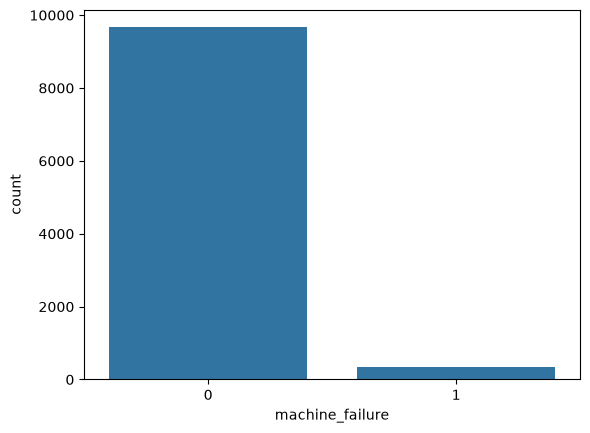

In [55]:
sns.countplot(data=df, x="machine_failure", )
plt.show()

- Target is highly imbalanced.

In [ ]:
failure_cols = [
    "twf",
    "hdf",
    "pwf",
    "osf",
    "rnf"
]

df[failure_cols].sum().sort_values()

rnf     19
twf     46
pwf     95
osf     98
hdf    115
dtype: int64

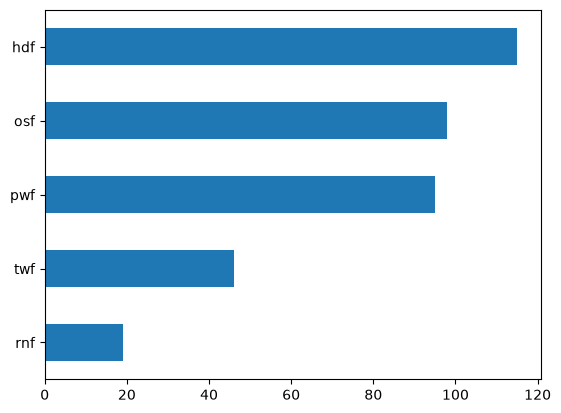

In [72]:
df[failure_cols].sum().sort_values().plot(kind="barh")
plt.show()

- Heat Dissipation Failure (HDF) is the most frequent failure mechanism in this dataset.
- random failures (RNF) is the lowest

In [87]:
sensor_features = [
    "air_temperature",
    "process_temperature",
    "rotational_speed",
    "torque",
    "tool_wear",
]

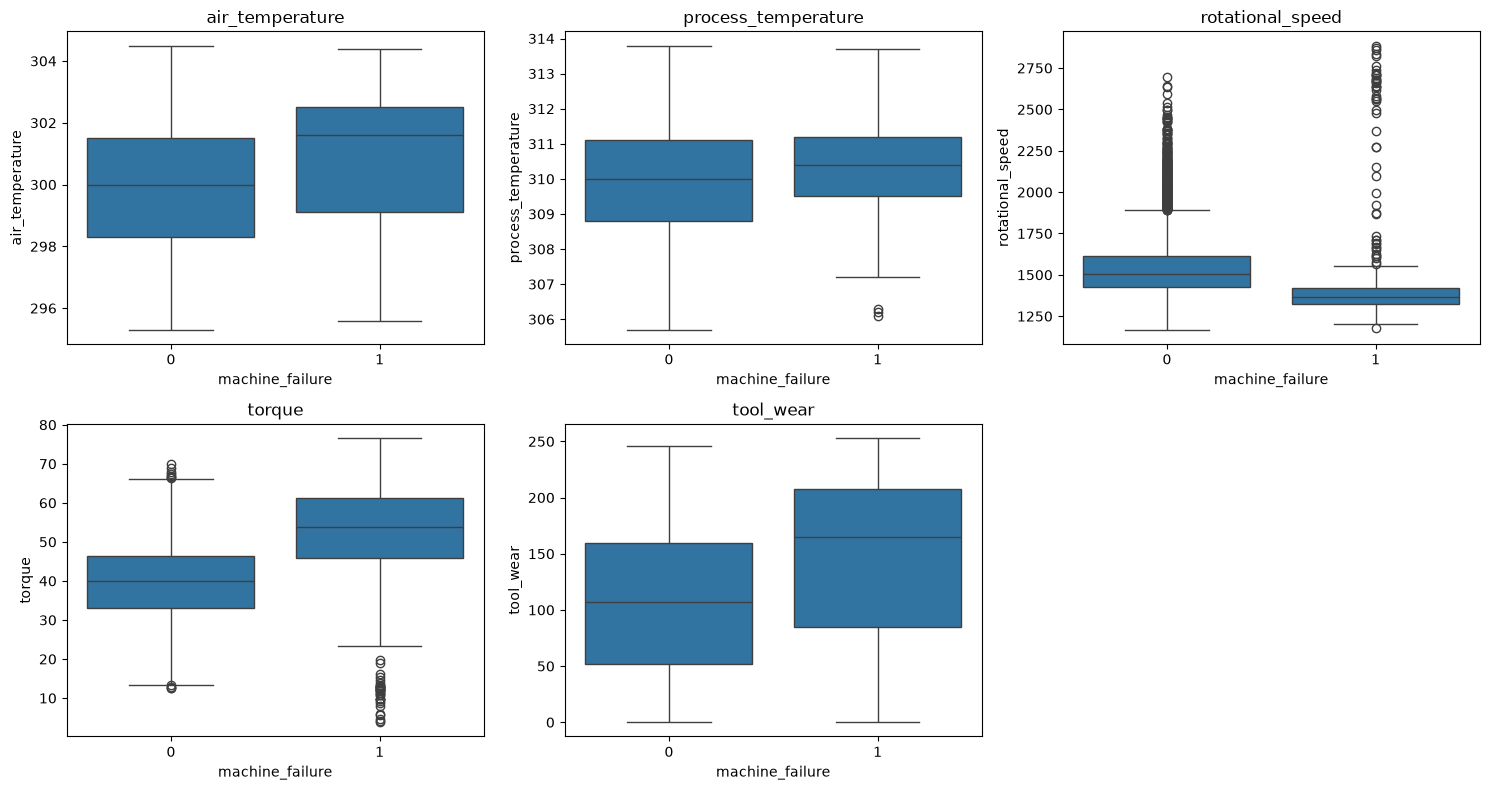

In [88]:
plt.figure(figsize=(15,8))

for i, col in enumerate(sensor_features, start=1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df,
        x="machine_failure",
        y=col)
    plt.title(col)

plt.tight_layout()
plt.show()

- Torque, tool wear, and rotational speed exhibit more noticeable differences and may provide stronger predictive value.

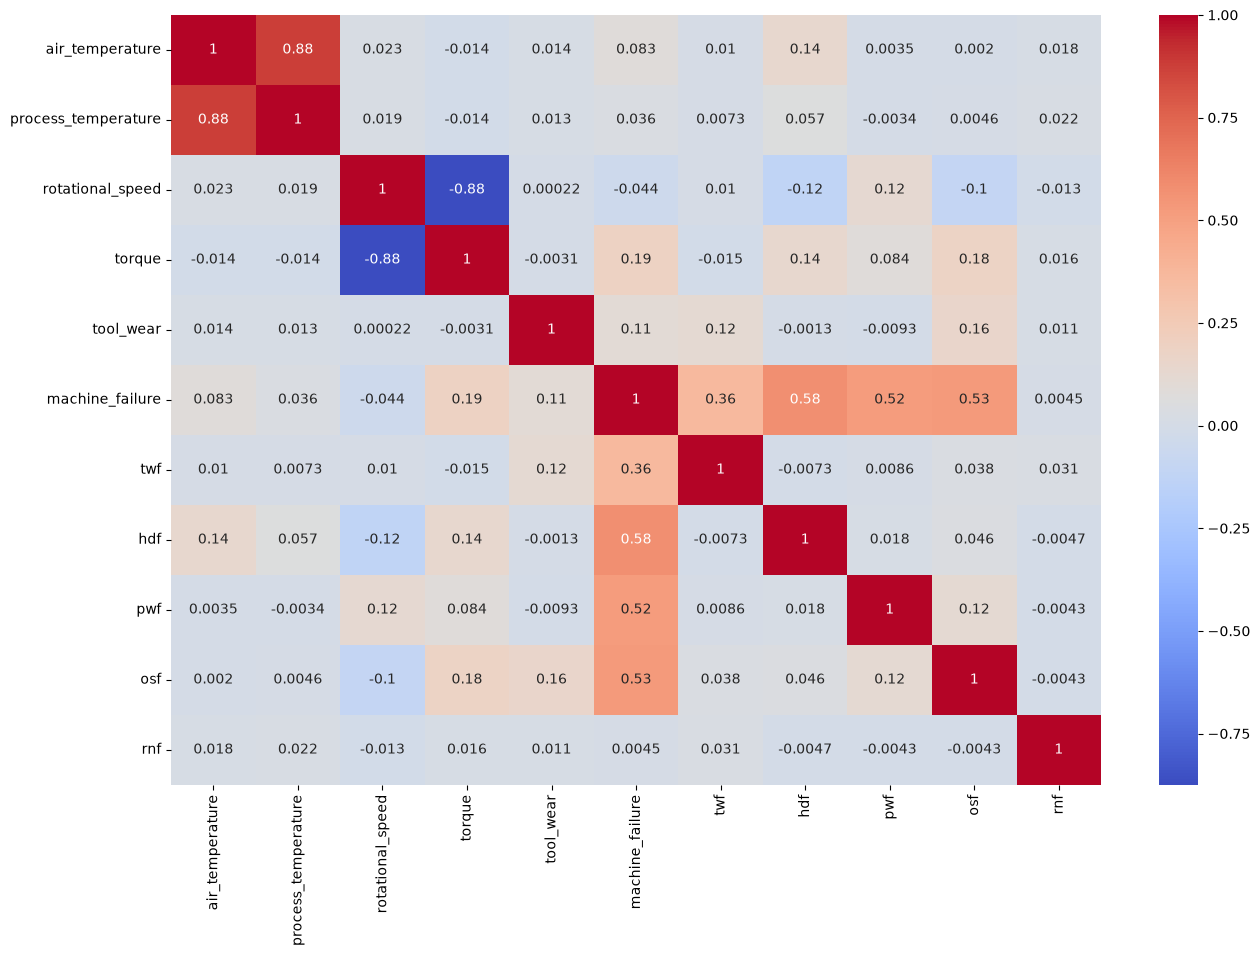

In [86]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

- Torque and rotational speed have high correlation (≈ -0.88).
- Air temperature and process temperature have high correlation (≈ 0.88).

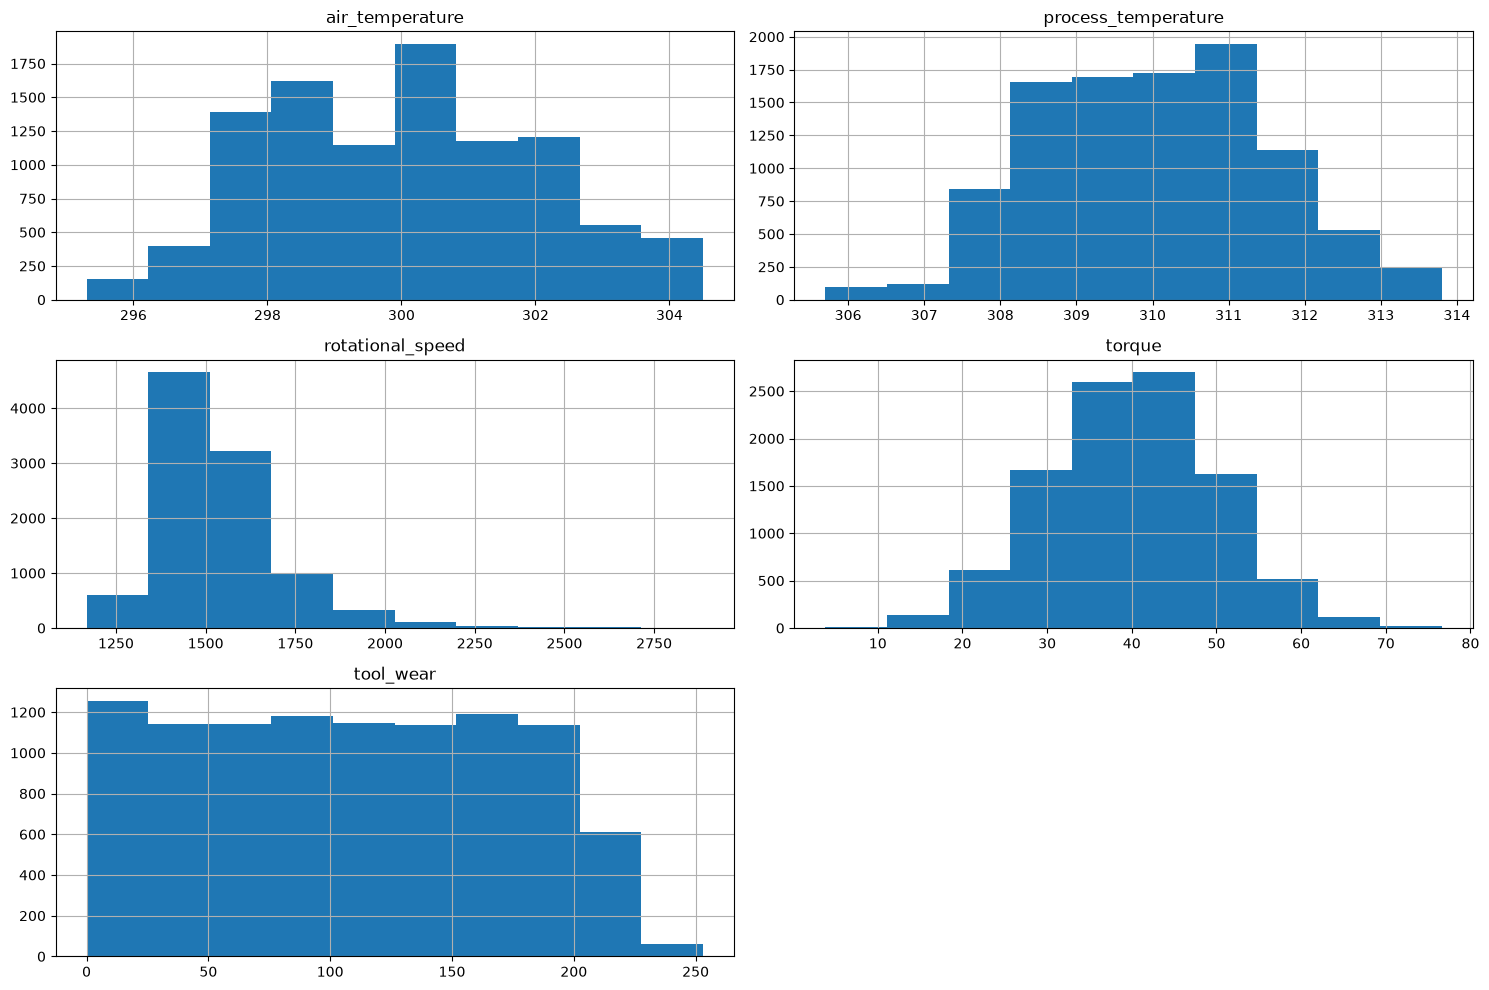

In [89]:
df[sensor_features].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

- Rotational speed exhibits a positively skewed distribution. Most machines operate between approximately 1350 and 1650 RPM, while a small number operate at substantially higher speeds.

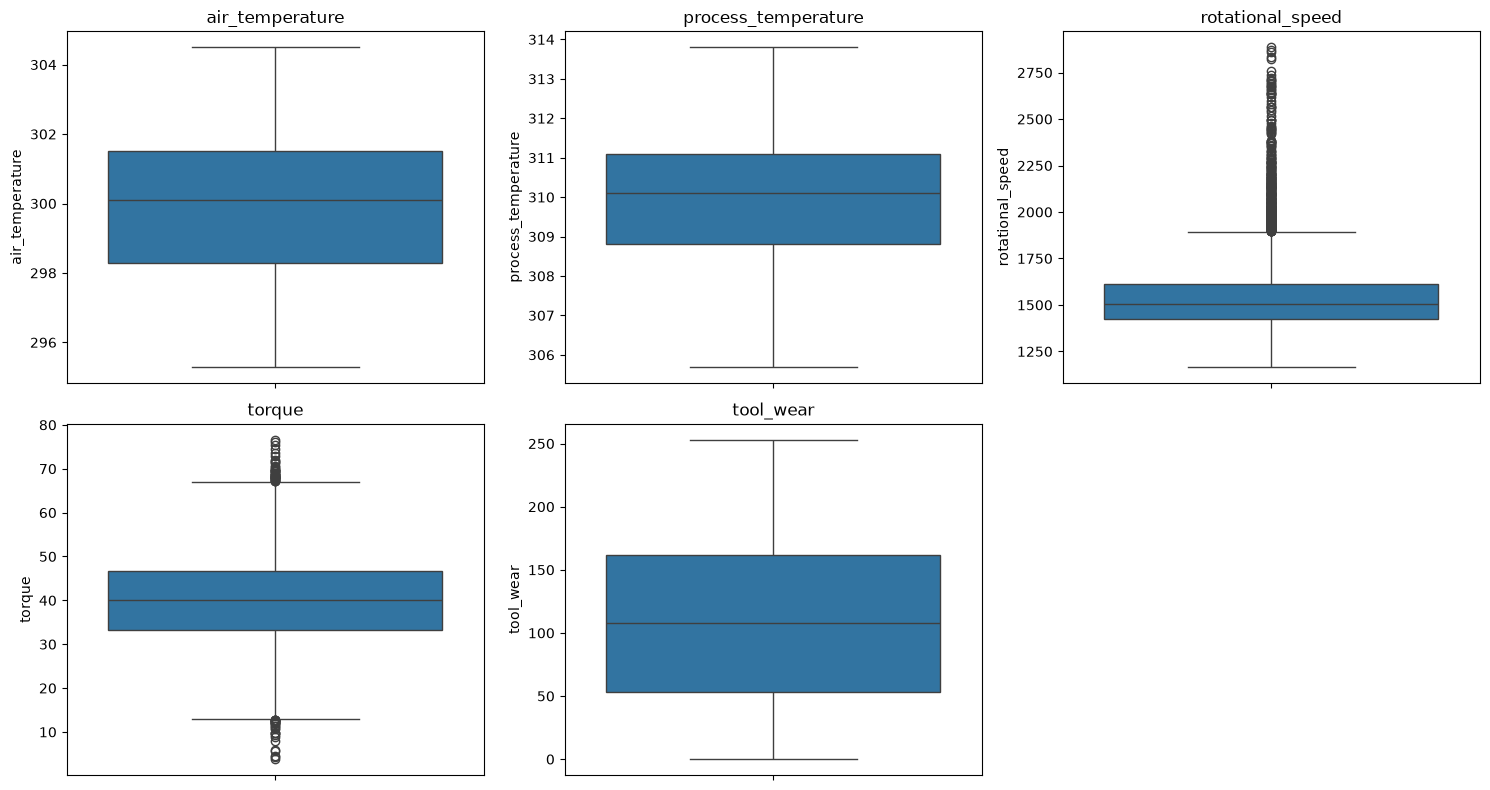

In [90]:
plt.figure(figsize=(15,8))

for i, col in enumerate(sensor_features, start=1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

- Rotational speed contains numerous high-value observations. These may represent legitimate high-speed operating conditions

In [81]:
df[df["rotational_speed"] > 1900]["machine_failure"].value_counts(normalize=True)

machine_failure
0    0.914634
1    0.085366
Name: proportion, dtype: float64

- Among machines operating above 1900 RPM, the failure rate is approximately 8.5%, compared with an overall dataset failure rate of 3.4%.

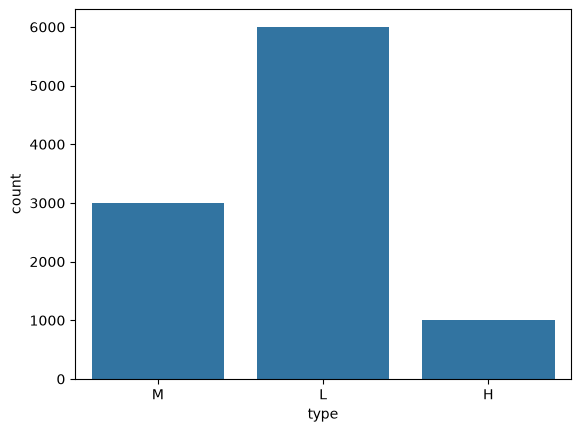

In [59]:
sns.countplot(data=df, x="type")
plt.show()

In [73]:
pd.crosstab(
    df["type"],
    df["machine_failure"],
    normalize="index"
)

machine_failure,0,1
type,,
H,0.979063,0.020937
L,0.960833,0.039167
M,0.972306,0.027694


- Machine type appears to have only a weak relationship with machine failure. The L-type machines exhibit a slightly higher failure rate than the other machine types, although the difference is relatively small.

In [91]:
df.groupby("machine_failure")[sensor_features].mean()

,air_temperature,process_temperature,rotational_speed,torque,tool_wear
machine_failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


- Failed machines experience substantially higher torque.
- Failed machines tend to have much more worn tools.
- Failed machines have lower average rotational speed (~44 RPM lower).

# EDA Summary

## Data Quality

- No missing values.
- No duplicate observations.

## Target

- Machine failures are highly imbalanced (~3.4%).

## Feature Insights

- Failed machines tend to operate at lower rotational speeds.
- Failed machines experience higher torque.
- Failed machines have significantly greater tool wear.
- Air and process temperatures show relatively small differences between classes.
- Torque, tool wear, and rotational speed exhibit more noticeable differences and may provide stronger predictive value.

## Correlation

- Torque and rotational speed are strongly negatively correlated (≈ -0.88).
- Air temperature and process temperature have high correlation (≈ 0.88).

## Outliers

- High rotational-speed observations appear to be valid operating conditions rather than obvious data errors.